In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import os
import time
from tqdm.notebook import tqdm
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [8]:
DATA_DIR = '/home/inonzr/datasets/samsung/20260219_174631/'
NUM_CLASSES = 5
BATCH_SIZE = 128
EPOCHS = 70
LEARNING_RATE = 1e-3
IMAGE_SIZE = 50
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
DATASET_MEAN = [0.5223926305770874, 0.5005241632461548, 0.49497371912002563]
DATASET_STD = [0.14497309923171997, 0.14863280951976776, 0.14289118349552155]


Using device: cuda


In [9]:
def calculate_dataset_stats(data_dir):
    print("Calculating mean and std for the custom Samsung dataset...")

    temp_transform = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor()
    ])

    temp_dataset = datasets.ImageFolder(data_dir, transform=temp_transform)
    temp_loader = DataLoader(temp_dataset, batch_size=64, shuffle=False, num_workers=4)

    mean = torch.zeros(3)
    std = torch.zeros(3)
    total_images = 0

    for images, _ in tqdm(temp_loader, desc="Calculating Stats"):
        batch_size = images.size(0)
        images = images.view(batch_size, images.size(1), -1)
        mean += images.mean(2).sum(0)
        std += images.std(2).sum(0)
        total_images += batch_size

    mean /= total_images
    std /= total_images
    DATASET_MEAN = mean
    DATASET_STD = std
    print("\n" + "="*50)
    print("DATASET STATISTICS CALCULATED!")
    print(f"DATASET_MEAN = {mean.tolist()}")
    print(f"DATASET_STD  = {std.tolist()}")
    print("="*50)
    print("Please copy these values to the Hyperparameters cell at the top.\n")
    return mean, std
calculate_dataset_stats(DATA_DIR)

Calculating mean and std for the custom Samsung dataset...


Calculating Stats:   0%|          | 0/110 [00:00<?, ?it/s]


DATASET STATISTICS CALCULATED!
DATASET_MEAN = [0.5223926305770874, 0.5005241632461548, 0.49497371912002563]
DATASET_STD  = [0.14497309923171997, 0.14863280951976776, 0.14289118349552155]
Please copy these values to the Hyperparameters cell at the top.



(tensor([0.5224, 0.5005, 0.4950]), tensor([0.1450, 0.1486, 0.1429]))

In [10]:
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=DATASET_MEAN, std=DATASET_STD)
])

val_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=DATASET_MEAN, std=DATASET_STD)
])
print(DATASET_STD)
print(DATASET_MEAN)

[0.14497309923171997, 0.14863280951976776, 0.14289118349552155]
[0.5223926305770874, 0.5005241632461548, 0.49497371912002563]


In [11]:
def get_dataloaders(data_dir, batch_size):

    full_train_dataset = datasets.ImageFolder(data_dir, transform=train_transforms)
    full_val_dataset = datasets.ImageFolder(data_dir, transform=val_transforms)

    classes = full_train_dataset.classes
    dataset_size = len(full_train_dataset)

    indices = torch.randperm(dataset_size).tolist()

    split_idx = int(0.2 * dataset_size)

    val_indices = indices[:split_idx]
    train_indices = indices[split_idx:]

    train_dataset = Subset(full_train_dataset, train_indices)
    val_dataset = Subset(full_val_dataset, val_indices)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

    print(f"\nDataset loaded successfully!")
    print(f"Total images: {dataset_size}")
    print(f"Training on:  {len(train_dataset)} images (80%)")
    print(f"Validating on:{len(val_dataset)} images (20%)")
    print(f"Classes: {classes}\n")

    return train_loader, val_loader, classes

In [12]:
class SEBlock(nn.Module):

    def __init__(self, in_channels, reduction=16):
        super(SEBlock, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(in_channels, in_channels // reduction, bias=False),
            nn.GELU(),
            nn.Linear(in_channels // reduction, in_channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class ResidualBlock(nn.Module):

    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.gelu = nn.GELU()

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.se = SEBlock(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = self.gelu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.se(out)
        out += self.shortcut(x)
        out = self.gelu(out)
        return out

class SamsungDefectDetector(nn.Module):

    def __init__(self, num_classes=5):
        super(SamsungDefectDetector, self).__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.GELU()
        )

        self.layer1 = ResidualBlock(64, 128, stride=2)
        self.layer2 = ResidualBlock(128, 256, stride=2)
        self.layer3 = ResidualBlock(256, 512, stride=2)
        self.layer4 = ResidualBlock(512, 1024, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(1024, 512),
            nn.GELU(),
            nn.Dropout(p=0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)

        return x



In [13]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.ce_loss = nn.CrossEntropyLoss(reduction='none')

    def forward(self, inputs, targets):
        ce_loss = self.ce_loss(inputs, targets)
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss


In [14]:
def train_model():
    print("Loading data...")
    train_loader, val_loader, classes = get_dataloaders(DATA_DIR, BATCH_SIZE)
    print(f"Found classes: {classes}")

    model = SamsungDefectDetector(num_classes=NUM_CLASSES).to(device)

    criterion = FocalLoss(gamma=2.0)
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    best_acc = 0.0

    print("Starting training...")
    for epoch in range(EPOCHS):
        start_time = time.time()

        model.train()
        running_loss = 0.0
        corrects = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            corrects += torch.sum(preds == labels.data)
            total += inputs.size(0)

        train_loss = running_loss / total
        train_acc = corrects.double() / total

        model.eval()
        val_loss = 0.0
        val_corrects = 0
        val_total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                _, preds = torch.max(outputs, 1)
                val_loss += loss.item() * inputs.size(0)
                val_corrects += torch.sum(preds == labels.data)
                val_total += inputs.size(0)

        val_loss = val_loss / val_total
        val_acc = val_corrects.double() / val_total

        scheduler.step()

        epoch_time = time.time() - start_time

        print(f"Epoch {epoch+1}/{EPOCHS} | Time: {epoch_time:.0f}s")
        print(f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f}")
        print(f"Val Loss:   {val_loss:.4f} Acc: {val_acc:.4f}")

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), 'best_samsung_model.pth')
            print(">>> Best model saved! <<<")
        print("-" * 40)

    print(f"Training complete. Best Validation Accuracy: {best_acc:.4f}")


In [15]:
def show_model_layers():
    print("Loading model architecture...")
    model = SamsungDefectDetector(num_classes=NUM_CLASSES)

    print("\n" + "="*50)
    print("MODEL ARCHITECTURE (LAYERS)")
    print("="*50)
    print(model)

    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print("\n" + "="*50)
    print("MODEL SUMMARY")
    print("="*50)
    print(f"Total Parameters:      {total_params:,}")
    print(f"Trainable Parameters:  {trainable_params:,}")
    print("="*50 + "\n")


In [16]:
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

def train_model():
    print(" Starting Samsung AI Training...")
    train_loader, val_loader, classes = get_dataloaders(DATA_DIR, BATCH_SIZE)

    model = SamsungDefectDetector(num_classes=NUM_CLASSES).to(device)
    criterion = FocalLoss(gamma=2.0)
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_acc = 0.0
    patience = 7
    epochs_no_improve = 0

    for epoch in range(EPOCHS):
        model.train()
        running_loss, corrects, total = 0.0, 0, 0
        train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False, colour='#ff6666')

        for inputs, labels in train_loop:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            corrects += torch.sum(preds == labels.data)
            total += inputs.size(0)
            train_loop.set_postfix(loss=f"{loss.item():.3f}")

        epoch_loss = running_loss / total
        epoch_acc = (corrects.double() / total).item()

        model.eval()
        val_loss, val_corrects, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)
                val_loss += loss.item() * inputs.size(0)
                val_corrects += torch.sum(preds == labels.data)
                val_total += inputs.size(0)

        val_epoch_loss = val_loss / val_total
        val_acc = (val_corrects.double() / val_total).item()

        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc)
        history['val_loss'].append(val_epoch_loss)
        history['val_acc'].append(val_acc)

        print(f" [Epoch {epoch+1:02d}] Train Loss: {epoch_loss:.4f} | Val Acc: {val_acc:.2%}")

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), 'best_samsung_model.pth')
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print("\n Early stopping triggered.")
            break
        scheduler.step()

    return model, history, classes

In [17]:
model, history, classes = train_model()

 Starting Samsung AI Training...

Dataset loaded successfully!
Total images: 7025
Training on:  5620 images (80%)
Validating on:1405 images (20%)
Classes: ['Broken Line', 'Edge False Color', 'Over Desaturation', 'Saturated False Color', 'Smears']



Epoch 1/70:   0%|          | 0/44 [00:00<?, ?it/s]

 [Epoch 01] Train Loss: 0.8140 | Val Acc: 50.46%


Epoch 2/70:   0%|          | 0/44 [00:00<?, ?it/s]

 [Epoch 02] Train Loss: 0.6483 | Val Acc: 61.71%


...

 [Epoch 32] Train Loss: 0.1622 | Val Acc: 79.07%


Epoch 33/70:   0%|          | 0/44 [00:00<?, ?it/s]

 [Epoch 33] Train Loss: 0.1519 | Val Acc: 80.00%


Epoch 34/70:   0%|          | 0/44 [00:00<?, ?it/s]

 [Epoch 34] Train Loss: 0.1487 | Val Acc: 79.29%

 Early stopping triggered.


In [18]:


def plot_metrics(history, all_labels=None, all_preds=None):
    # הגדרת ציר ה-X לפי מספר האפוקים
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(15, 5))

    #  Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'ro-', label='Train Loss')
    plt.plot(epochs, history['val_loss'], 'bo-', label='Val Loss')
    plt.title('Training & Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    #  Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], 'ro-', label='Train Acc')
    plt.plot(epochs, history['val_acc'], 'bo-', label='Val Acc')
    plt.title('Training & Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    if all_labels and all_preds:
        cm = confusion_matrix(all_labels, all_preds)

        classes = ['Broken Line', 'Edge False Color', 'Over Desaturation', 'Saturated False Color', 'Smears']

        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

        fig, ax = plt.subplots(figsize=(10, 8))

        disp.plot(ax=ax, cmap='Blues', xticks_rotation='vertical')
        plt.title('Confusion Matrix')
        plt.tight_layout()
        plt.show()

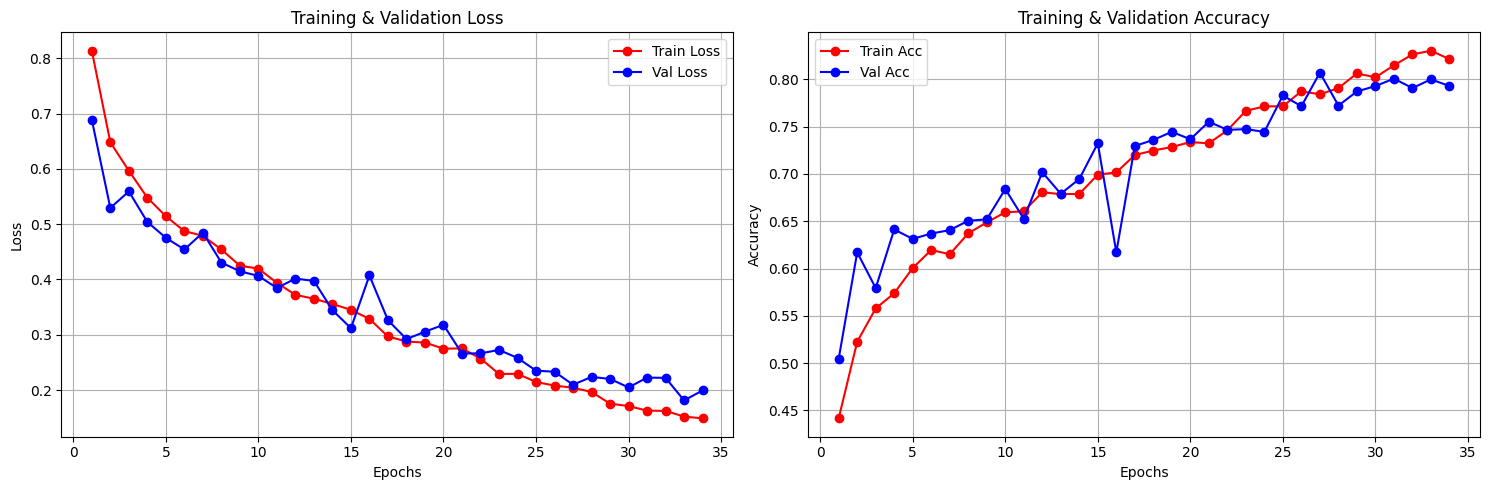

In [19]:
plot_metrics(history)


Dataset loaded successfully!
Total images: 7025
Training on:  5620 images (80%)
Validating on:1405 images (20%)
Classes: ['Broken Line', 'Edge False Color', 'Over Desaturation', 'Saturated False Color', 'Smears']



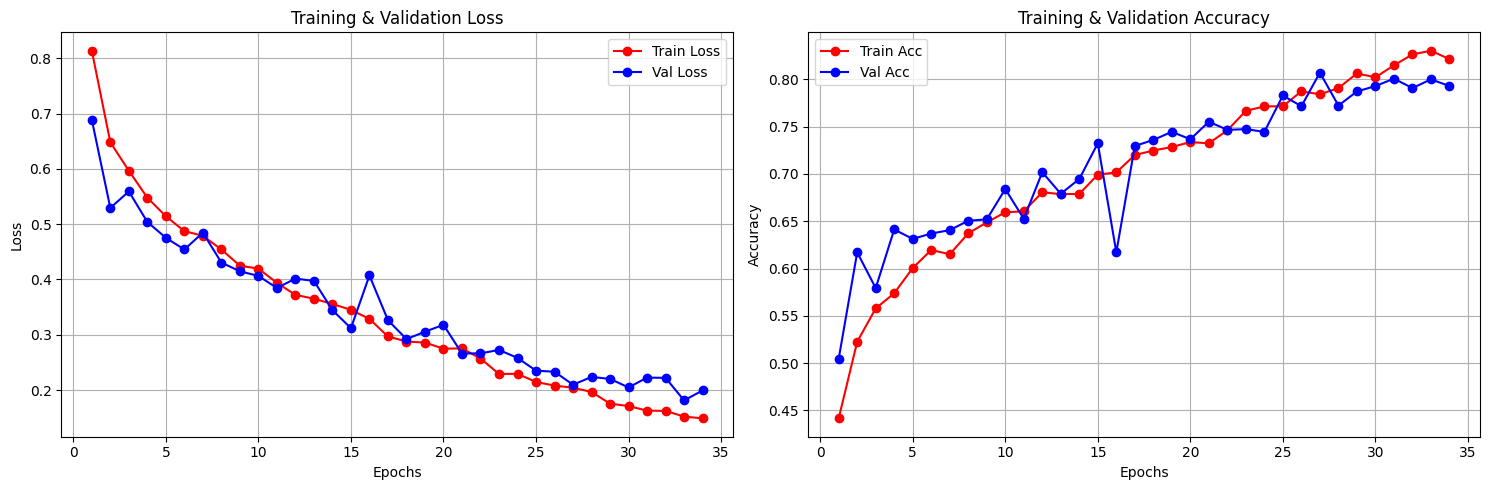

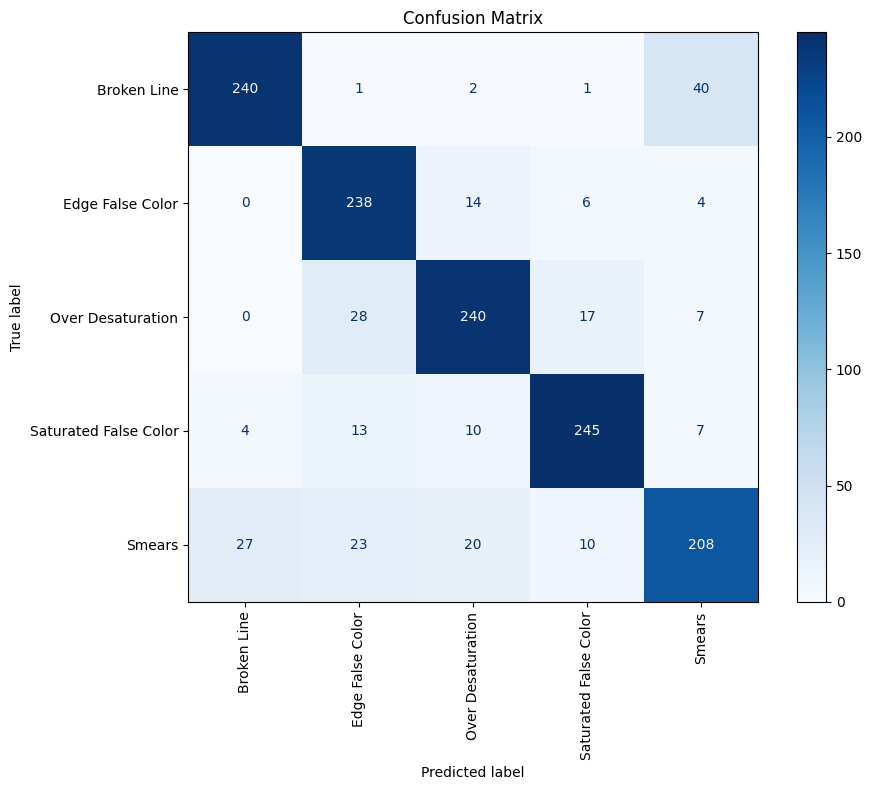

In [20]:
def get_val_predictions(model, val_loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    return all_labels, all_preds

_, val_loader, classes = get_dataloaders(DATA_DIR, BATCH_SIZE)
best_model = SamsungDefectDetector(num_classes=NUM_CLASSES).to(device)
best_model.load_state_dict(torch.load('best_samsung_model.pth', map_location=device))

print("Collecting predictions for Confusion Matrix...")
true_labels, model_predictions = get_val_predictions(best_model, val_loader, device)

plot_metrics(history, all_labels=true_labels, all_preds=model_predictions)

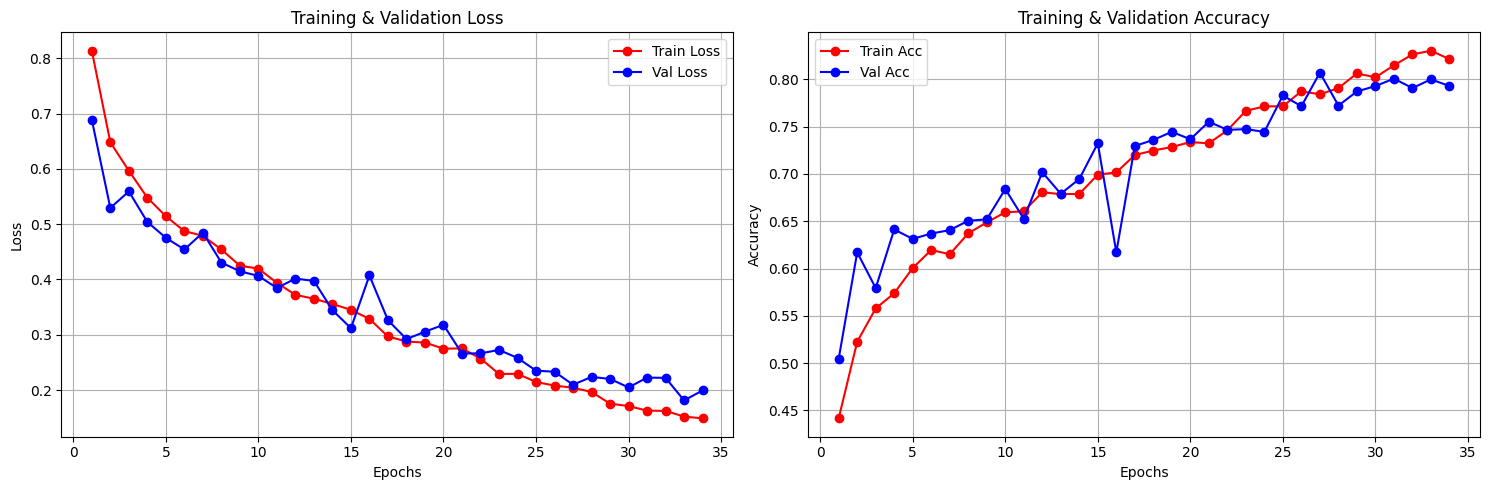

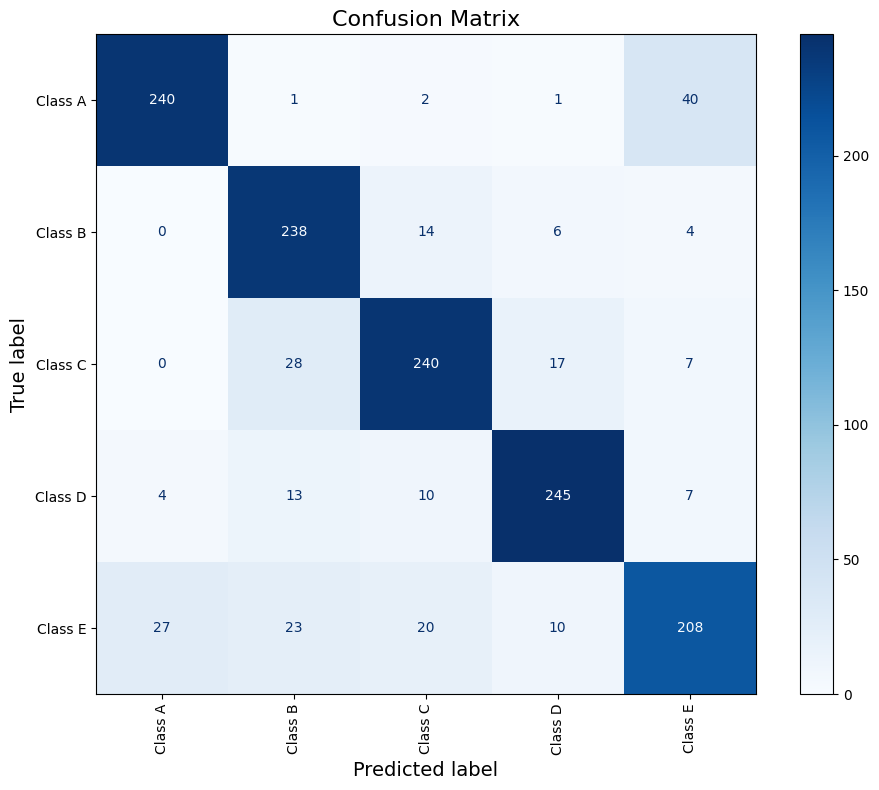

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_metrics_full(history, all_labels=None, all_preds=None):
    epochs = range(1, len(history['train_loss']) + 1)
    plt.figure(figsize=(15, 5))

    #  Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'ro-', label='Train Loss')
    plt.plot(epochs, history['val_loss'], 'bo-', label='Val Loss')
    plt.title('Training & Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    #  Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], 'ro-', label='Train Acc')
    plt.plot(epochs, history['val_acc'], 'bo-', label='Val Acc')
    plt.title('Training & Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    if all_labels and all_preds:
        cm = confusion_matrix(all_labels, all_preds)

        classes = ['Class A', 'Class B', 'Class C', 'Class D', 'Class E']

        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

        fig, ax = plt.subplots(figsize=(10, 8))


        disp.plot(ax=ax, cmap='Blues', xticks_rotation='vertical')

        plt.title('Confusion Matrix', fontsize=16)
        ax.set_xlabel('Predicted label', fontsize=14)
        ax.set_ylabel('True label', fontsize=14)

        plt.tight_layout()
        plt.show()
plot_metrics_full(history, all_labels=true_labels, all_preds=model_predictions)


Dataset loaded successfully!
Total images: 7025
Training on:  5620 images (80%)
Validating on:1405 images (20%)
Classes: ['Broken Line', 'Edge False Color', 'Over Desaturation', 'Saturated False Color', 'Smears']



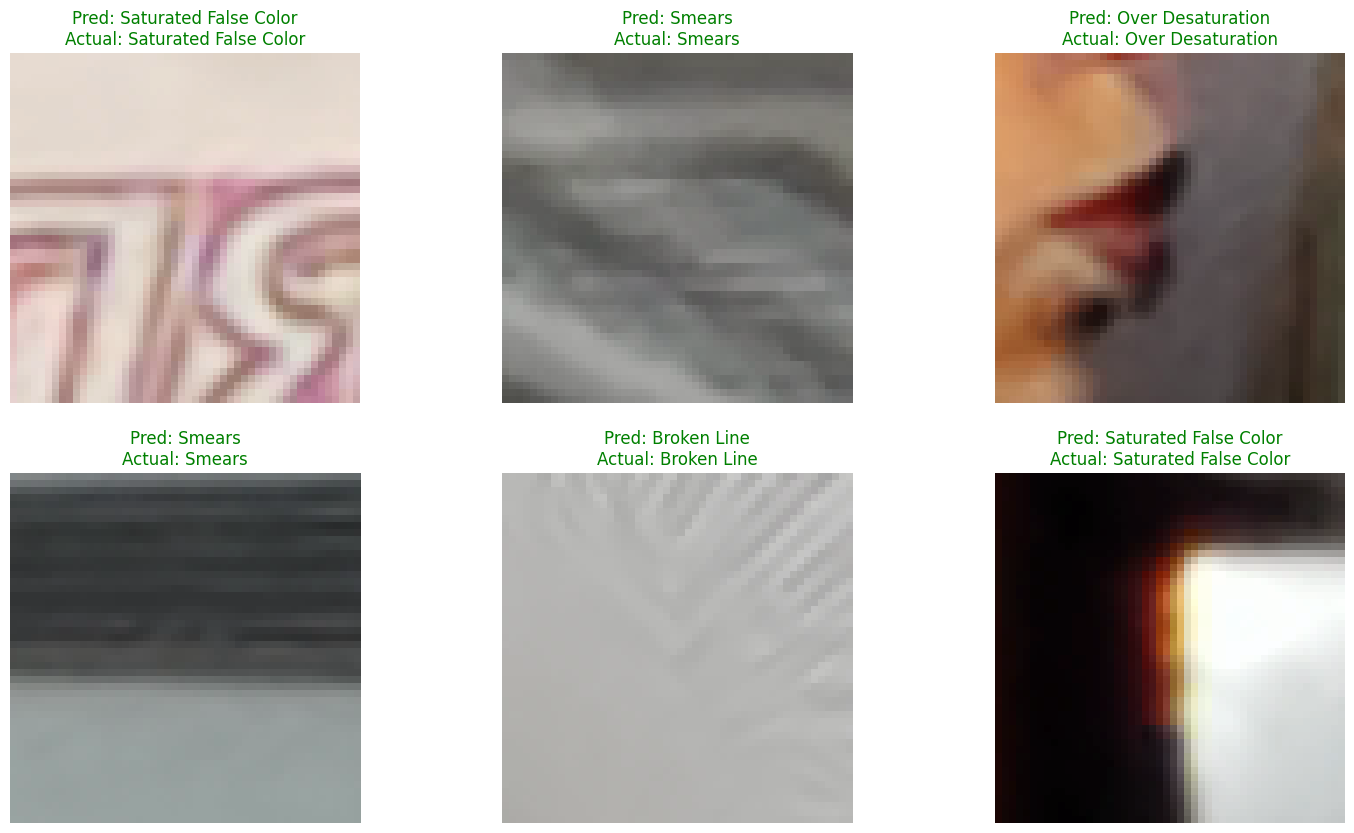

In [22]:
def visualize_results(model, data_dir, classes, num_images=6):
    model.eval()
    _, val_loader, _ = get_dataloaders(data_dir, batch_size=num_images)
    inputs, labels = next(iter(val_loader))
    inputs, labels = inputs.to(device), labels.to(device)

    outputs = model(inputs)
    _, preds = torch.max(outputs, 1)

    plt.figure(figsize=(18, 10))
    for i in range(num_images):
        plt.subplot(2, 3, i + 1)
        img = inputs[i].cpu().numpy().transpose((1, 2, 0))
        img = DATASET_STD * img + DATASET_MEAN
        img = img.clip(0, 1)

        color = 'green' if preds[i] == labels[i] else 'red'
        plt.imshow(img)
        plt.title(f"Pred: {classes[preds[i]]}\nActual: {classes[labels[i]]}", color=color)
        plt.axis('off')
    plt.show()

visualize_results(model, DATA_DIR, classes)

In [23]:
total_params = sum(p.numel() for p in model.parameters())

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")

Total Parameters: 20,211,781
Trainable Parameters: 20,211,781


In [24]:
from torchsummary import summary

summary(model, input_size=(3, 50, 50))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 50, 50]           1,728
       BatchNorm2d-2           [-1, 64, 50, 50]             128
              GELU-3           [-1, 64, 50, 50]               0
            Conv2d-4          [-1, 128, 25, 25]          73,728
       BatchNorm2d-5          [-1, 128, 25, 25]             256
              GELU-6          [-1, 128, 25, 25]               0
            Conv2d-7          [-1, 128, 25, 25]         147,456
       BatchNorm2d-8          [-1, 128, 25, 25]             256
 AdaptiveAvgPool2d-9            [-1, 128, 1, 1]               0
           Linear-10                    [-1, 8]           1,024
             GELU-11                    [-1, 8]               0
           Linear-12                  [-1, 128]           1,024
          Sigmoid-13                  [-1, 128]               0
          SEBlock-14          [-1, 128,

1. Extracting features from the model...
2. Reducing dimensions with t-SNE...
3. Running DBSCAN...
4. Plotting results...


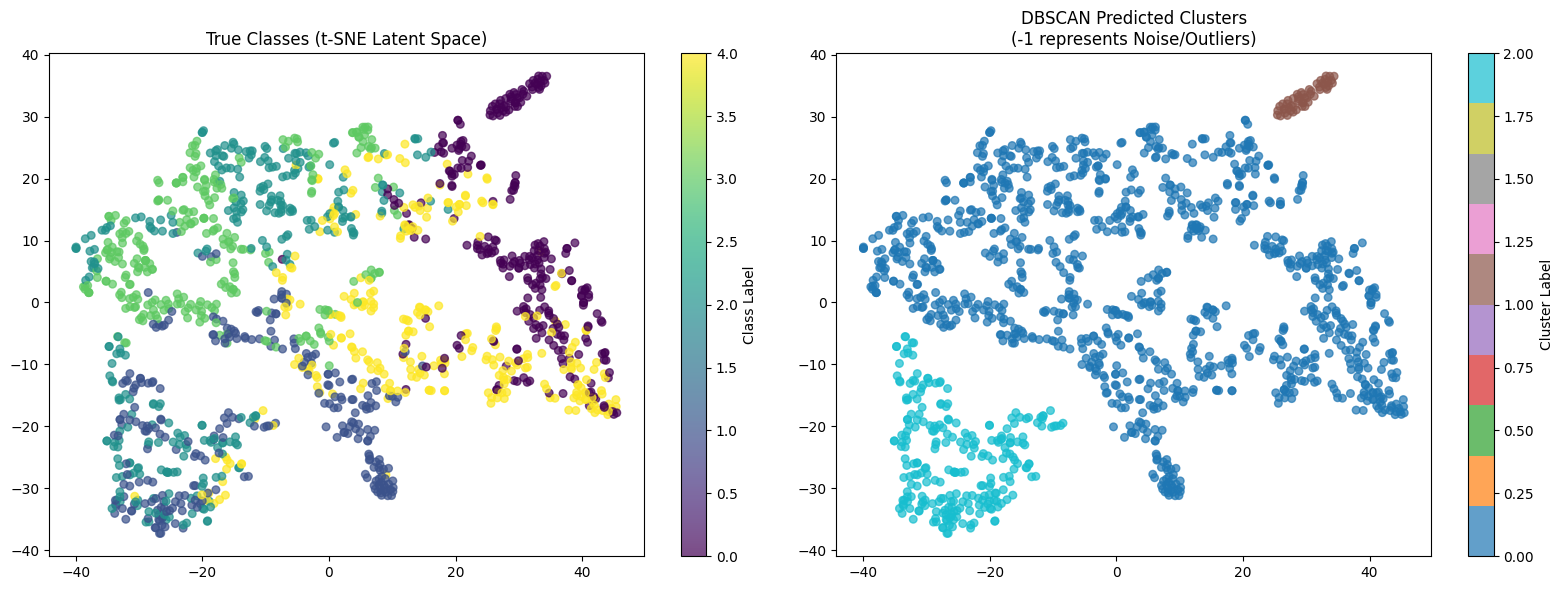

Estimated number of valid clusters: 3
Estimated number of noise points: 0


In [25]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.manifold import TSNE

def extract_latent_features(model, dataloader, device):

    model.eval()
    features = []
    labels_list = []


    activation = {}
    def get_activation(name):
        def hook(model, input, output):
            activation[name] = output.detach()
        return hook



    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs)


            feat = outputs.cpu().numpy()

            features.append(feat)
            labels_list.append(labels.numpy())

    return np.vstack(features), np.concatenate(labels_list)

print("1. Extracting features from the model...")
features, true_labels = extract_latent_features(model, val_loader, device)

print("2. Reducing dimensions with t-SNE...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
features_2d = tsne.fit_transform(features)

print("3. Running DBSCAN...")

dbscan = DBSCAN(eps=3.5, min_samples=5)
cluster_labels = dbscan.fit_predict(features_2d)

print("4. Plotting results...")
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
scatter1 = plt.scatter(features_2d[:, 0], features_2d[:, 1], c=true_labels, cmap='viridis', s=30, alpha=0.7)
plt.title("True Classes (t-SNE Latent Space)")
plt.colorbar(scatter1, label="Class Label")

plt.subplot(1, 2, 2)
scatter2 = plt.scatter(features_2d[:, 0], features_2d[:, 1], c=cluster_labels, cmap='tab10', s=30, alpha=0.7)
plt.title("DBSCAN Predicted Clusters\n(-1 represents Noise/Outliers)")
plt.colorbar(scatter2, label="Cluster Label")

plt.tight_layout()
plt.show()

n_clusters_ = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise_ = list(cluster_labels).count(-1)
print(f"Estimated number of valid clusters: {n_clusters_}")
print(f"Estimated number of noise points: {n_noise_}")